In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# 재실행용 환경 복구(2일차여서 그래요)
import os
import random
import shutil
import tarfile
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import scipy.io as sio
import cv2
import matplotlib.pyplot as plt

from PIL import ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

from torch.utils.data import DataLoader

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
CUDA: True
GPU: Tesla T4


In [3]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher"
)

DATA_DIR = DRIVE_ROOT / "data" / "class_activation_map"
MODEL_DIR = DRIVE_ROOT / "models" / "class_activation_map"
OUTPUT_DIR = DRIVE_ROOT / "outputs" / "class_activation_map"

RUNTIME_ROOT = Path("/content/class_activation_map")

for path in [
    DATA_DIR,
    MODEL_DIR,
    OUTPUT_DIR,
    RUNTIME_ROOT,
]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device)

device: cuda


In [4]:
# 데이터 복구. 코랩 특성상 한번 닫으면 다시 해야해요.
archives = [
    "images.tar",
    "annotation.tar",
    "lists.tar",
]

for filename in archives:
    archive_path = DATA_DIR / filename

    print("[EXTRACT]", filename)

    with tarfile.open(archive_path) as tar:
        tar.extractall(RUNTIME_ROOT)

print("Extraction complete")

[EXTRACT] images.tar


/tmp/ipykernel_631/1012387078.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(RUNTIME_ROOT)


[EXTRACT] annotation.tar
[EXTRACT] lists.tar
Extraction complete


In [5]:
# 재현성 고정. 이제 t4 런타임 간당간당하므로... 더욱 중요
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("seed  :", SEED)
print("device:", device)

seed  : 42
device: cuda


## train과 test 이미지 폴더 만들기

In [6]:
images_dir = RUNTIME_ROOT / "Images"

train_mat = sio.loadmat(
    RUNTIME_ROOT / "train_list.mat"
)

test_mat = sio.loadmat(
    RUNTIME_ROOT / "test_list.mat"
)

train_file_list = train_mat["file_list"]
test_file_list = test_mat["file_list"]

BASE_DIR = RUNTIME_ROOT / "stanford_dogs"
TRAIN_DIR = BASE_DIR / "train"
VALID_DIR = BASE_DIR / "test"

TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VALID_DIR.mkdir(parents=True, exist_ok=True)


def process_mat_file(
    file_list_array,
    split_dir,
):
    for idx in range(
        file_list_array.shape[0]
    ):
        file_path = (
            file_list_array[idx][0]
            .item()
        )

        if isinstance(file_path, bytes):
            file_path = file_path.decode(
                "utf-8"
            )

        class_folder = file_path.split("/")[0]

        dest_folder = (
            split_dir / class_folder
        )

        dest_folder.mkdir(
            parents=True,
            exist_ok=True,
        )

        src_path = images_dir / file_path
        dest_path = (
            dest_folder
            / Path(file_path).name
        )

        if not dest_path.exists():
            shutil.copy(
                src_path,
                dest_path,
            )


process_mat_file(
    train_file_list,
    TRAIN_DIR,
)

process_mat_file(
    test_file_list,
    VALID_DIR,
)

print("Dataset ready")

Dataset ready


## 데이터셋과 BBOX
이번 프로젝트의 BBOX 표준은



```
(x_min, y_min, x_max, y_max)
```



In [8]:
ImageFile.LOAD_TRUNCATED_IMAGES = True


class StanfordDogsDatasetWithBBox(
    datasets.ImageFolder
):
    def __init__(
        self,
        root,
        annotation_root,
        transform=None,
    ):
        super().__init__(
            root,
            transform=transform,
        )

        self.annotation_root = Path(
            annotation_root
        )

        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(
            index
        )

        path, _ = self.samples[index]
        path = Path(path)

        rel_path = path.relative_to(
            self.root
        )

        annot_path = (
            self.annotation_root
            / rel_path.parent
            / rel_path.stem
        )

        bbox = [
            0.0,
            0.0,
            0.0,
            0.0,
        ]

        if annot_path.exists():
            tree = ET.parse(annot_path)
            root_xml = tree.getroot()

            obj = root_xml.find("object")

            if obj is not None:
                bndbox = obj.find(
                    "bndbox"
                )

                xmin = float(
                    bndbox.find("xmin").text
                )
                ymin = float(
                    bndbox.find("ymin").text
                )
                xmax = float(
                    bndbox.find("xmax").text
                )
                ymax = float(
                    bndbox.find("ymax").text
                )

                size = root_xml.find("size")

                w = float(
                    size.find("width").text
                )
                h = float(
                    size.find("height").text
                )

                new_h, new_w = (
                    self.new_size
                )

                bbox = [
                    xmin * (new_w / w),
                    ymin * (new_h / h),
                    xmax * (new_w / w),
                    ymax * (new_h / h),
                ]

        return (
            image,
            label,
            torch.tensor(
                bbox,
                dtype=torch.float32,
            ),
        )

## 위의 작업이 흥미로운 점:


```
원본 이미지 좌표의 Ground Truth

(xmin, ymin, xmax, ymax)
           │
           │ 이미지가 224×224로 Resize됨
           ▼
224×224 기준으로 좌표도 Resize

(xmin', ymin', xmax', ymax')
```



In [9]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

ANNOTATION_DIR = (
    RUNTIME_ROOT / "Annotation"
)

train_dataset = StanfordDogsDatasetWithBBox(
    root=TRAIN_DIR,
    annotation_root=ANNOTATION_DIR,
    transform=transform,
)

valid_dataset = StanfordDogsDatasetWithBBox(
    root=VALID_DIR,
    annotation_root=ANNOTATION_DIR,
    transform=transform,
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

num_classes = len(
    train_dataset.classes
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Classes:", num_classes)

Train: 12000
Valid: 8580
Classes: 120


In [ ]:
# ImageNet normalization 전처리

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

ANNOTATION_DIR = RUNTIME_ROOT / "Annotation"

train_dataset = StanfordDogsDatasetWithBBox(
    root=TRAIN_DIR,
    annotation_root=ANNOTATION_DIR,
    transform=transform,
)

valid_dataset = StanfordDogsDatasetWithBBox(
    root=VALID_DIR,
    annotation_root=ANNOTATION_DIR,
    transform=transform,
)

print("Classes :", len(train_dataset.classes))
print("Train   :", len(train_dataset))
print("Valid   :", len(valid_dataset))

Classes : 120
Train   : 12000
Valid   : 8580


In [10]:
# 미리 2 epoch 해둔 어제 모델 재구현하기
CAM_MODEL_PATH = (
    MODEL_DIR
    / "cam_resnet50_stanford_dogs.pt"
)

checkpoint = torch.load(
    CAM_MODEL_PATH,
    map_location=device,
)

model = models.resnet50(
    weights=None
)

num_ftrs = model.fc.in_features

model.fc = nn.Linear(
    num_ftrs,
    num_classes,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

history = checkpoint["history"]

print("Model restored")
print(
    "Last validation accuracy:",
    history["valid_acc"][-1],
)

Model restored
Last validation accuracy: 0.8061771561771561


In [12]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [13]:
print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    ),
)

Trainable parameters: 245880


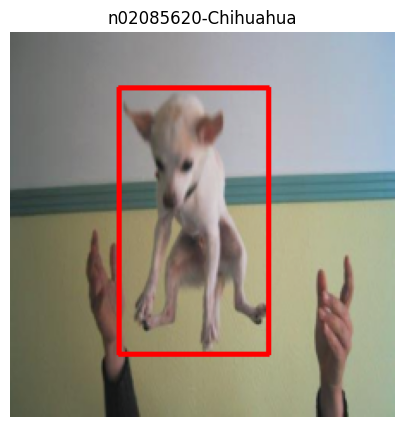

BBox: [63, 32, 150, 187]


In [14]:
# 비박스 한 장 검증. 좌표가 틀리면 IoU까지 전부 뒤틀리기 때문!
import matplotlib.pyplot as plt
import numpy as np
import cv2


IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])


def unnormalize(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = IMAGENET_STD * img + IMAGENET_MEAN
    img = np.clip(img, 0, 1)
    return np.uint8(img * 255)


image, label, bbox = train_dataset[0]

img = unnormalize(image)
bbox_int = [int(v) for v in bbox.tolist()]

x_min, y_min, x_max, y_max = bbox_int

img_box = img.copy()

cv2.rectangle(
    img_box,
    (x_min, y_min),
    (x_max, y_max),
    (255, 0, 0),
    2,
)

plt.figure(figsize=(5, 5))
plt.imshow(img_box)
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

print("BBox:", bbox_int)

In [ ]:
%%time

history = train_model(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    num_epochs=2,
)


Epoch 1/2
  Step  100 | Loss 1.2441
  Step  200 | Loss 1.1650
  Step  300 | Loss 0.8785
Train      | Loss 1.6241 | Acc 61.27%
Validation | Loss 0.7516 | Acc 78.05%

Epoch 2/2
  Step  100 | Loss 0.9449
  Step  200 | Loss 1.1024
  Step  300 | Loss 0.6254
Train      | Loss 0.6872 | Acc 80.19%
Validation | Loss 0.6440 | Acc 80.62%
CPU times: user 1min 11s, sys: 7.57 s, total: 1min 18s
Wall time: 3min 26s


In [ ]:
CAM_MODEL_PATH = MODEL_DIR / "cam_resnet50_stanford_dogs.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "classes": train_dataset.classes,
        "history": history,
        "weights": "IMAGENET1K_V1",
        "image_size": 224,
        "seed": SEED,
    },
    CAM_MODEL_PATH,
)

print("✅ Saved:", CAM_MODEL_PATH)

✅ Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/class_activation_map/cam_resnet50_stanford_dogs.pt


| Metric          | Epoch 1 |    Epoch 2 |       변화 |
| --------------- | ------: | ---------: | -------: |
| Train Loss      |  1.6241 | **0.6872** |    크게 감소 |
| Train Acc       |  61.27% | **80.19%** | +18.92%p |
| Validation Loss |  0.7516 | **0.6440** |       감소 |
| Validation Acc  |  78.05% | **80.62%** |  +2.57%p |


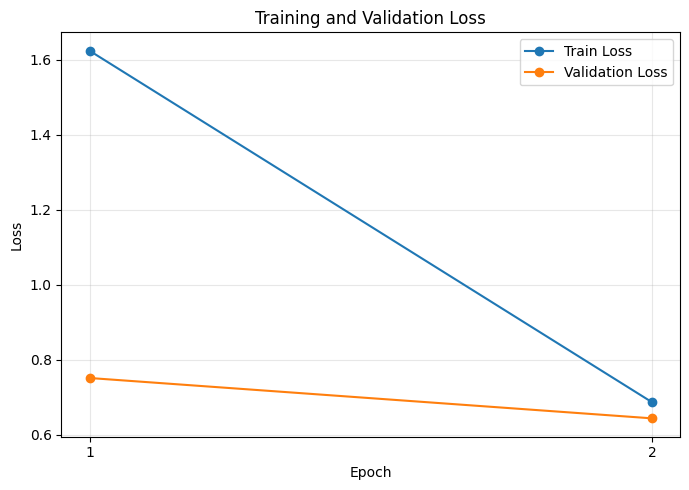

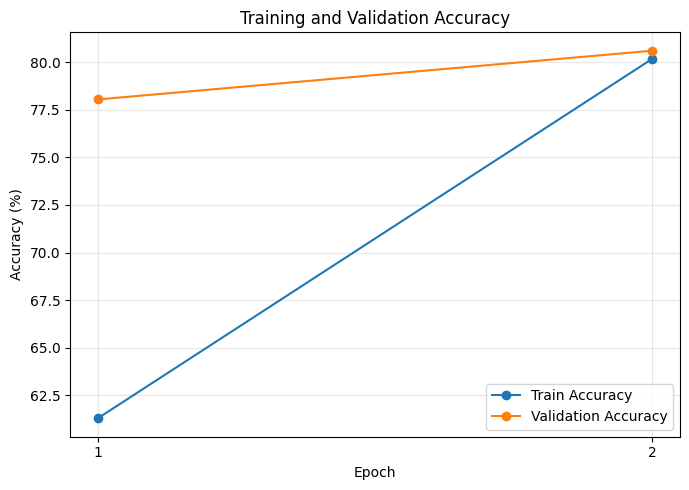

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/class_activation_map/training_loss.png
Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/class_activation_map/training_accuracy.png


In [ ]:
# 부족한 자원으로... 벌써 학습 수렴 시각화

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["valid_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_path = OUTPUT_DIR / "training_loss.png"
plt.savefig(loss_path, dpi=150)
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(
    epochs,
    np.array(history["train_acc"]) * 100,
    marker="o",
    label="Train Accuracy",
)
plt.plot(
    epochs,
    np.array(history["valid_acc"]) * 100,
    marker="o",
    label="Validation Accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

acc_path = OUTPUT_DIR / "training_accuracy.png"
plt.savefig(acc_path, dpi=150)
plt.show()

print("Saved:", loss_path)
print("Saved:", acc_path)

## CAM 구현



```
layer4 Feature Maps
       ↓
각 채널 × 해당 class의 FC weight
       ↓
모두 합산
       ↓
ReLU
       ↓
0~1 Normalize
       ↓
CAM
```



In [15]:
# CAM 구현

def generate_cam(model, item):
    model.eval()

    image, _, _ = item
    input_tensor = image.unsqueeze(0).to(device)

    activations = {}

    # ResNet50 마지막 convolution block의 출력을 저장
    def forward_hook(module, inputs, output):
        activations["value"] = output.detach()

    handle = model.layer4.register_forward_hook(forward_hook)

    with torch.no_grad():
        output = model(input_tensor)

    handle.remove()

    # 현재 모델이 예측한 class
    pred_class = output.argmax(dim=1).item()

    # [1, C, H, W] -> [C, H, W]
    feature_maps = activations["value"][0]

    # [num_classes, C] 중 예측 class의 weight
    class_weights = model.fc.weight[pred_class].detach()

    # CAM = 각 feature map × class weight의 합
    cam_image = torch.zeros(
        feature_maps.shape[1:],
        device=feature_maps.device,
    )

    for channel, weight in zip(feature_maps, class_weights):
        cam_image += weight * channel

    # 해당 class에 양의 기여를 하는 부분만 유지
    cam_image = F.relu(cam_image)

    # 0~1 정규화
    cam_image -= cam_image.min()
    cam_image /= cam_image.max() + 1e-8

    return cam_image.cpu().numpy()

In [16]:
# 정답 예측 validation sample 찾기

def find_correct_sample(model, dataset, max_search=500):
    model.eval()

    for idx in range(min(max_search, len(dataset))):
        image, label, bbox = dataset[idx]

        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device))

        pred = output.argmax(dim=1).item()

        if pred == label:
            return idx, dataset[idx], pred

    raise RuntimeError("Correct sample not found.")


sample_idx, item, pred_class = find_correct_sample(
    model,
    valid_dataset,
)

image, label, ground_bbox = item

print("Sample index :", sample_idx)
print("Ground truth :", valid_dataset.classes[label])
print("Prediction   :", valid_dataset.classes[pred_class])
print("GT BBox      :", ground_bbox.tolist())

Sample index : 0
Ground truth : n02085620-Chihuahua
Prediction   : n02085620-Chihuahua
GT BBox      : [16.816816329956055, 4.480000019073486, 185.65765380859375, 223.10400390625]


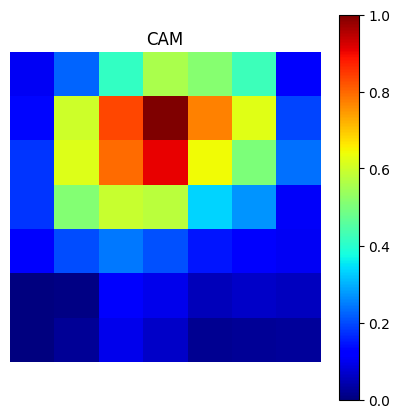

CAM shape: (7, 7)
CAM range: 0.0 ~ 1.0


In [17]:
# 치와와 보기.
import torch.nn.functional as F
cam_image = generate_cam(model, item)

plt.figure(figsize=(5, 5))
plt.imshow(cam_image, cmap="jet")
plt.colorbar()
plt.title("CAM")
plt.axis("off")
plt.show()

print("CAM shape:", cam_image.shape)
print("CAM range:", cam_image.min(), "~", cam_image.max())

## 원본과 CAM 이미지 합성하기

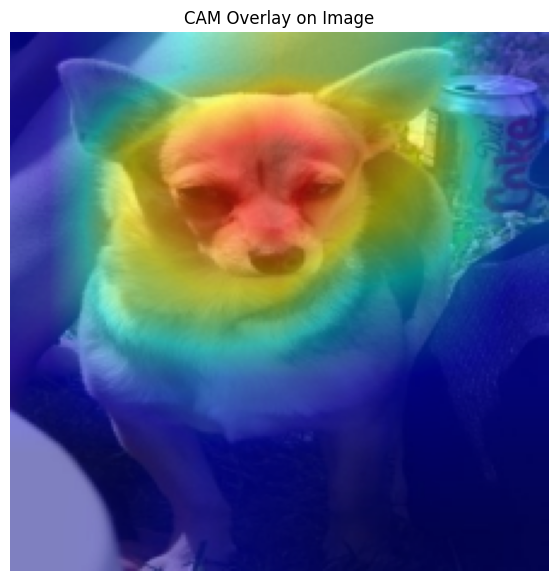

In [18]:
def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM: 작은 feature map → 원본 224×224로 확대
    cam_resized = cv2.resize(
        cam,
        (img.shape[1], img.shape[0]),
        interpolation=cv2.INTER_LINEAR,
    )

    # 0~1 → 0~255
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized),
        cv2.COLORMAP_JET,
    )

    # OpenCV BGR → matplotlib RGB
    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB,
    )

    overlay = cv2.addWeighted(
        img,
        1 - alpha,
        heatmap,
        alpha,
        0,
    )

    plt.figure(figsize=(7, 7))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis("off")
    plt.show()

    return overlay


orig_img = unnormalize(image)

cam_overlay = visualize_cam_on_image(
    cam_image,
    orig_img,
)

## GRAD-CAM 구현

In [19]:
# 백본을 freeze 해서 학습했으므로 grad 계산 시 입력 텐서에 기울기를 활성화해야함.

def generate_grad_cam(model, activation_layer, item):
    model.eval()

    image, _, _ = item

    input_tensor = (
        image.unsqueeze(0)
        .to(device)
        .requires_grad_(True)
    )

    activations = {}
    gradients = {}

    def forward_hook(module, inputs, output):
        activations["value"] = output

        # 해당 activation에 대한 gradient 저장
        output.register_hook(
            lambda grad: gradients.update({"value": grad})
        )

    handle = activation_layer.register_forward_hook(
        forward_hook
    )

    model.zero_grad(set_to_none=True)

    output = model(input_tensor)

    pred_class = output.argmax(dim=1).item()

    # 예측된 class의 logit
    class_score = output[0, pred_class]

    class_score.backward()

    handle.remove()

    # [1, C, H, W] -> [C, H, W]
    feature_maps = activations["value"][0]
    grads = gradients["value"][0]

    # 각 channel gradient의 spatial average
    weights = grads.mean(dim=(1, 2))

    grad_cam_image = torch.zeros(
        feature_maps.shape[1:],
        device=feature_maps.device,
    )

    for channel, weight in zip(feature_maps, weights):
        grad_cam_image += weight * channel

    # 양의 class contribution만 남김
    grad_cam_image = F.relu(grad_cam_image)

    grad_cam_image -= grad_cam_image.min()
    grad_cam_image /= grad_cam_image.max() + 1e-8

    return grad_cam_image.detach().cpu().numpy()

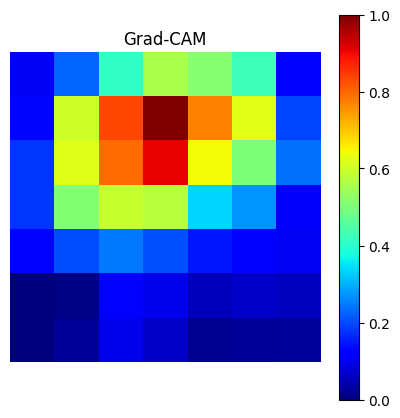

Grad-CAM shape: (7, 7)


In [20]:
grad_cam_image = generate_grad_cam(
    model,
    model.layer4,
    item,
)

plt.figure(figsize=(5, 5))
plt.imshow(grad_cam_image, cmap="jet")
plt.colorbar()
plt.title("Grad-CAM")
plt.axis("off")
plt.show()

print("Grad-CAM shape:", grad_cam_image.shape)

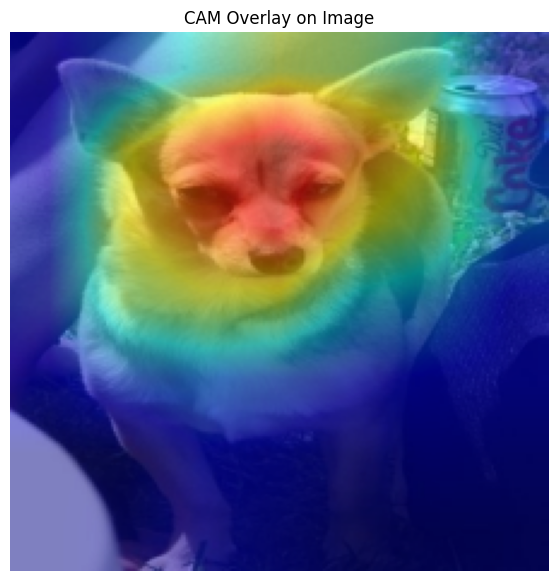

In [21]:
# 원본에 오버레이
grad_cam_overlay = visualize_cam_on_image(
    grad_cam_image,
    orig_img,
)

## CAM에 바운딩 박스 입히기

In [22]:
# Heatmap -> Bounding Box

def get_bbox(cam, threshold=0.5):
    coords = np.argwhere(cam > threshold)

    if coords.size == 0:
        return None

    # argwhere: (y, x)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    return (
        int(x_min),
        int(y_min),
        int(x_max),
        int(y_max),
    )


THRESHOLD = 0.5

cam_resized = cv2.resize(
    cam_image,
    (224, 224),
)

grad_cam_resized = cv2.resize(
    grad_cam_image,
    (224, 224),
)

cam_bbox = get_bbox(
    cam_resized,
    threshold=THRESHOLD,
)

grad_cam_bbox = get_bbox(
    grad_cam_resized,
    threshold=THRESHOLD,
)

gt_bbox = tuple(
    int(v) for v in ground_bbox.tolist()
)

print("Ground Truth :", gt_bbox)
print("CAM BBox     :", cam_bbox)
print("Grad-CAM BBox:", grad_cam_bbox)

Ground Truth : (16, 4, 185, 223)
CAM BBox     : (39, 0, 184, 119)
Grad-CAM BBox: (39, 0, 184, 119)


## BBOX 시각화

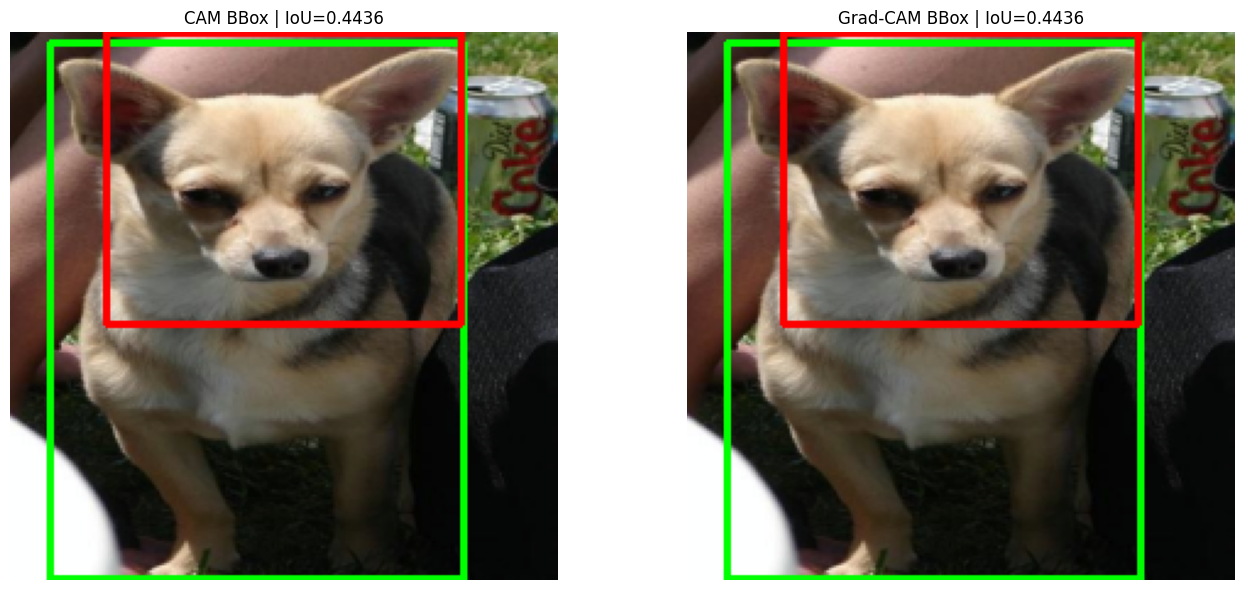

Green: Ground Truth
Red  : Predicted BBox


In [26]:
# CAM / Grad-CAM Bounding Box와 Ground Truth 시각화

def draw_bbox_comparison(
    img,
    gt_bbox,
    pred_bbox,
    title,
):
    result = img.copy()

    # Ground Truth: green
    if gt_bbox is not None:
        gx1, gy1, gx2, gy2 = map(int, gt_bbox)
        cv2.rectangle(
            result,
            (gx1, gy1),
            (gx2, gy2),
            (0, 255, 0),
            2,
        )

    # Prediction: red
    if pred_bbox is not None:
        px1, py1, px2, py2 = map(int, pred_bbox)
        cv2.rectangle(
            result,
            (px1, py1),
            (px2, py2),
            (255, 0, 0),
            2,
        )

    plt.imshow(result)
    plt.title(title)
    plt.axis("off")


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
draw_bbox_comparison(
    orig_img,
    gt_bbox,
    cam_bbox,
    f"CAM BBox | IoU={cam_iou:.4f}",
)

plt.subplot(1, 2, 2)
draw_bbox_comparison(
    orig_img,
    gt_bbox,
    grad_cam_bbox,
    f"Grad-CAM BBox | IoU={grad_cam_iou:.4f}",
)

plt.tight_layout()
plt.show()

print("Green: Ground Truth")
print("Red  : Predicted BBox")

## IoU 구현

In [24]:
def get_iou(gt_bbox, pred_bbox):
    if gt_bbox is None or pred_bbox is None:
        return 0.0

    gx1, gy1, gx2, gy2 = gt_bbox
    px1, py1, px2, py2 = pred_bbox

    # Intersection
    ix1 = max(gx1, px1)
    iy1 = max(gy1, py1)
    ix2 = min(gx2, px2)
    iy2 = min(gy2, py2)

    inter_w = max(0, ix2 - ix1)
    inter_h = max(0, iy2 - iy1)

    intersection = inter_w * inter_h

    gt_area = max(0, gx2 - gx1) * max(0, gy2 - gy1)
    pred_area = max(0, px2 - px1) * max(0, py2 - py1)

    union = gt_area + pred_area - intersection

    if union <= 0:
        return 0.0

    return intersection / union

In [25]:
# 계산
cam_iou = get_iou(
    gt_bbox,
    cam_bbox,
)

grad_cam_iou = get_iou(
    gt_bbox,
    grad_cam_bbox,
)

print(f"CAM IoU      : {cam_iou:.4f}")
print(f"Grad-CAM IoU : {grad_cam_iou:.4f}")

CAM IoU      : 0.4436
Grad-CAM IoU : 0.4436


In [27]:
# 여러 validation sample에서 CAM vs Grad-CAM IoU 비교

N_SAMPLES = 50

cam_ious = []
grad_cam_ious = []

for idx in range(N_SAMPLES):
    sample = valid_dataset[idx]

    image_i, label_i, gt_bbox_i = sample

    cam_i = generate_cam(
        model,
        sample,
    )

    grad_cam_i = generate_grad_cam(
        model,
        model.layer4,
        sample,
    )

    cam_i = cv2.resize(
        cam_i,
        (224, 224),
    )

    grad_cam_i = cv2.resize(
        grad_cam_i,
        (224, 224),
    )

    cam_bbox_i = get_bbox(
        cam_i,
        threshold=THRESHOLD,
    )

    grad_bbox_i = get_bbox(
        grad_cam_i,
        threshold=THRESHOLD,
    )

    gt_bbox_i = tuple(
        int(v) for v in gt_bbox_i.tolist()
    )

    cam_ious.append(
        get_iou(gt_bbox_i, cam_bbox_i)
    )

    grad_cam_ious.append(
        get_iou(gt_bbox_i, grad_bbox_i)
    )


cam_ious = np.array(cam_ious)
grad_cam_ious = np.array(grad_cam_ious)

print(f"Samples: {N_SAMPLES}")

print(
    f"CAM Mean IoU      : "
    f"{cam_ious.mean():.4f}"
)

print(
    f"Grad-CAM Mean IoU : "
    f"{grad_cam_ious.mean():.4f}"
)

print(
    f"CAM Median IoU      : "
    f"{np.median(cam_ious):.4f}"
)

print(
    f"Grad-CAM Median IoU : "
    f"{np.median(grad_cam_ious):.4f}"
)

print(
    "CAM better      :",
    np.sum(cam_ious > grad_cam_ious),
)

print(
    "Grad-CAM better :",
    np.sum(grad_cam_ious > cam_ious),
)

print(
    "Same            :",
    np.sum(
        np.isclose(
            cam_ious,
            grad_cam_ious,
        )
    ),
)

Samples: 50
CAM Mean IoU      : 0.4699
Grad-CAM Mean IoU : 0.4699
CAM Median IoU      : 0.4451
Grad-CAM Median IoU : 0.4451
CAM better      : 0
Grad-CAM better : 0
Same            : 50


## 지금까지 진행한 내용을 정리해보겠습니다.



```
┌──────────────────────────────────────────────────────────────┐
│                    Stanford Dogs Dataset                     │
│                                                              │
│  이미지                  견종 Label             정답 BBox     │
│  Chihuahua.jpg          Chihuahua           (x1,y1,x2,y2)    │
└───────────┬──────────────────┬──────────────────────┬─────────┘
            │                  │                      │
            │                  │ 분류 학습에 사용      │ 위치 평가는
            │                  ▼                      │ 마지막에만 사용
            │        ┌───────────────────┐            │
            └───────▶│     ResNet50      │            │
                     │ ImageNet pretrained│            │
                     └─────────┬─────────┘            │
                               │                      │
                               ▼                      │
                     ┌───────────────────┐            │
                     │ CNN Backbone      │            │
                     │ pretrained / freeze│           │
                     │                   │            │
                     │ edge → texture    │            │
                     │ → shape → object  │            │
                     └─────────┬─────────┘            │
                               │                      │
                               ▼                      │
                     ┌───────────────────┐            │
                     │ layer4 Feature Map│            │
                     │   C × 7 × 7       │            │
                     │                   │            │
                     │ "어디에서 어떤     │            │
                     │ 특징이 나타났는가" │            │
                     └─────────┬─────────┘            │
                               │
                               ▼
                     ┌───────────────────┐
                     │ GAP               │
                     │ Global Average    │
                     │ Pooling           │
                     │                   │
                     │ 7×7 → 채널별 1개 값│
                     └─────────┬─────────┘
                               │
                               ▼
                     ┌───────────────────┐
                     │ Dense / FC        │
                     │ 2048 → 120 classes│
                     └─────────┬─────────┘
                               │
                               ▼
                     ┌───────────────────┐
                     │ 견종 Classification│
                     │ ex. Chihuahua     │
                     └─────────┬─────────┘
                               │
                ┌──────────────┴──────────────┐
                │                             │
                ▼                             ▼
        ┌────────────────┐            ┌────────────────┐
        │      CAM       │            │    Grad-CAM    │
        │                │            │                │
        │ FC weight 이용 │            │ gradient 이용  │
        └───────┬────────┘            └───────┬────────┘
                │                             │
                ▼                             ▼
        ┌────────────────┐            ┌────────────────┐
        │ 7×7 Heatmap    │            │ 7×7 Heatmap    │
        │                │            │                │
        │ 분류에 중요했던 │            │ 분류에 양의     │
        │ 위치           │            │ 영향을 준 위치 │
        └───────┬────────┘            └───────┬────────┘
                │                             │
                │ Resize 224×224              │ Resize 224×224
                ▼                             ▼
        ┌────────────────┐            ┌────────────────┐
        │ 원본 + CAM     │            │ 원본 + Grad-CAM│
        │ Overlay        │            │ Overlay        │
        └───────┬────────┘            └───────┬────────┘
                │                             │
                │ threshold = 0.5             │ threshold = 0.5
                ▼                             ▼
        ┌────────────────┐            ┌────────────────┐
        │ CAM BBox       │            │ Grad-CAM BBox  │
        └───────┬────────┘            └───────┬────────┘
                │                             │
                └─────────────┬───────────────┘
                              │
                              ▼
                    ┌──────────────────┐
                    │ Stanford Dogs의  │◀───────────── 정답 BBox
                    │ Ground Truth BBox│
                    └─────────┬────────┘
                              │
                              ▼
                    ┌──────────────────┐
                    │       IoU        │
                    │                  │
                    │ CAM vs GT        │
                    │ Grad-CAM vs GT   │
                    └─────────┬────────┘
                              │
                              ▼
                 ┌─────────────────────────┐
                 │ Object Localization     │
                 │ 성능 비교 및 해석       │
                 └─────────────────────────┘
```



### 추가 분석 계획

CAM과 Grad-CAM의 localization 성능을 보다 정량적으로 비교하기 위해
Ground Truth와 예측 Bounding Box를 함께 시각화하고,
validation 50 samples에 대해 Mean/Median IoU를 비교하는 코드를 추가했다.

다만 본 실습에서는 Colab 런타임 제한으로 인해 아래 추가 분석 코드는
실행하지 못했다. 따라서 프로젝트의 정량적 결론은 앞서 수행한
단일 validation sample의 IoU 결과에 한정하여 해석한다.

# 프로젝트 중간 결과 및 학습 의의

이번 프로젝트에서는 Stanford Dogs 데이터셋과 ImageNet 사전학습 ResNet50을 이용하여 120개 견종 분류 모델을 구성하였다. 제한된 학습 시간과 자원을 고려하여 pretrained backbone은 고정하고 새로운 분류층을 학습하는 전이학습 방식을 사용하였다.

2 epoch 학습 결과 Train Loss는 1.6241에서 0.6872로, Validation Loss는 0.7516에서 0.6440으로 감소하였다. Validation Accuracy 역시 78.05%에서 80.62%로 상승하여 학습이 안정적으로 수렴하는 경향을 조금은 빠르게.. 확인했다.

학습된 모델의 마지막 convolution block인 layer4에서 7×7 feature map을 추출했다.

CAM에서는 classifier의 FC weight를 이용해 feature map을 가중합하였고, Grad-CAM에서는 target class score에 대한 gradient를 이용하여 각 feature map의 중요도를 계산했다.
두 방법 모두 치와와의 얼굴과 머리 주변에서 높은 활성도를 나타내어 모델이 실제 object의 주요 특징을 분류 근거로 사용하고 있다. 하지만 이론적으로 배웠던 것보다 픽셀이 너무 커서 놀랐다. 유용해보이지 않았달까?
(하지만 더 알아보니 이는 깊은 CNN에서 공간 해상도를 줄이는 대신 더 넓은 receptive field와 높은 수준의 의미 특징을 얻게 되는 과정의 결과라는 점을 이해했다. 따라서 CAM은 픽셀 단위의 정밀한 segmentation 결과라기보다 모델이 주로 참고한 대략적인 공간 영역을 설명하는 도구로 이해하는 것이 적절)

또한 activation map을 224×224 크기로 복원한 뒤 threshold 0.5를 적용하여 predicted bounding box를 생성했다.

Stanford Dogs Annotation에 포함된 Ground Truth Bounding Box는 모델 학습에는 사용하지 않고 localization 평가에만 활용했다.
따라서 본 실험은 image-level class label만으로 학습된 분류 모델의 공간적 판단 근거를 평가한다는 점에서 weakly supervised localization의 흐름과 연결된다.

선택한 치와와 샘플에서는 CAM과 Grad-CAM이 동일한 Bounding Box와 IoU를 나타냈다. ResNet50의 마지막 convolution feature map 뒤에 GAP와 Linear classifier가 직접 연결된 구조에서는 CAM의 classifier weight와 Grad-CAM에서 계산되는 gradient 기반 channel importance가 밀접한 관계를 가질 수 있다.

다만 이번 실험에서는 전체 validation set에 대한 비교를 수행하지 못했으므로 두 기법이 일반적으로 동일한 localization 성능을 가진다고 결론짓지는 못한다!

# 2일차. 3 epoch 추가 학습해보기

In [28]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.fc.parameters(),
    lr=0.01,
    momentum=0.9,
)

Epoch 2 기록


```
Train Acc  80.19%
Valid Acc  80.62%
```



In [30]:
def train_model(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    num_epochs=1,
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "valid_loss": [],
        "valid_acc": [],
    }

    for epoch in range(num_epochs):
        # TRAIN
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            if (batch_idx + 1) % 100 == 0:
                print(
                    f"  Step {batch_idx + 1:4d}"
                    f" | Loss {loss.item():.4f}"
                )

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # VALIDATION
        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item()

                preds = outputs.argmax(dim=1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        valid_loss = running_loss / len(valid_loader)
        valid_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        print(
            f"Train      "
            f"| Loss {train_loss:.4f}"
            f" | Acc {train_acc * 100:.2f}%"
        )

        print(
            f"Validation "
            f"| Loss {valid_loss:.4f}"
            f" | Acc {valid_acc * 100:.2f}%"
        )

    return history

In [31]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.fc.parameters(),
    lr=0.01,
    momentum=0.9,
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

Trainable parameters: 245880


In [32]:
history_epoch3 = train_model(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    num_epochs=1,
)


Epoch 1/1
  Step  100 | Loss 0.3108
  Step  200 | Loss 0.6161
  Step  300 | Loss 0.3911
Train      | Loss 0.5352 | Acc 83.98%
Validation | Loss 0.6201 | Acc 81.12%


In [33]:
# 오늘 진행한 epoch3 history에 붙이기
for key in history:
    history[key].extend(history_epoch3[key])

print("Total recorded epochs:", len(history["train_loss"]))

for epoch in range(len(history["train_loss"])):
    print(
        f"Epoch {epoch + 1}: "
        f"Train Loss={history['train_loss'][epoch]:.4f}, "
        f"Train Acc={history['train_acc'][epoch] * 100:.2f}% | "
        f"Val Loss={history['valid_loss'][epoch]:.4f}, "
        f"Val Acc={history['valid_acc'][epoch] * 100:.2f}%"
    )

Total recorded epochs: 3
Epoch 1: Train Loss=1.6241, Train Acc=61.27% | Val Loss=0.7516, Val Acc=78.05%
Epoch 2: Train Loss=0.6872, Train Acc=80.19% | Val Loss=0.6440, Val Acc=80.62%
Epoch 3: Train Loss=0.5352, Train Acc=83.98% | Val Loss=0.6201, Val Acc=81.12%


In [34]:
# epoch 4 진행~
history_epoch4 = train_model(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    num_epochs=1,
)


Epoch 1/1
  Step  100 | Loss 0.6666
  Step  200 | Loss 0.7398
  Step  300 | Loss 0.4017
Train      | Loss 0.4600 | Acc 86.73%
Validation | Loss 0.6104 | Acc 81.40%


In [35]:
for key in history:
    history[key].extend(history_epoch4[key])

print("Total recorded epochs:", len(history["train_loss"]))

Total recorded epochs: 4


In [36]:
history_epoch5 = train_model(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    num_epochs=1,
)


Epoch 1/1
  Step  100 | Loss 0.2660
  Step  200 | Loss 0.5934
  Step  300 | Loss 0.7030
Train      | Loss 0.4298 | Acc 87.22%
Validation | Loss 0.5963 | Acc 81.72%


## 아직 validation이 꺾이진 않았지만, 일반화 성능 향상이 둔화되고 있다고 보면서 이만 자원의 부족으로 마무리...

In [37]:
# epoch 5 히스토리에 붙이기
for key in history:
    history[key].extend(history_epoch5[key])

print("Total recorded epochs:", len(history["train_loss"]))

for epoch in range(len(history["train_loss"])):
    print(
        f"Epoch {epoch + 1}: "
        f"Train Loss={history['train_loss'][epoch]:.4f}, "
        f"Train Acc={history['train_acc'][epoch] * 100:.2f}% | "
        f"Val Loss={history['valid_loss'][epoch]:.4f}, "
        f"Val Acc={history['valid_acc'][epoch] * 100:.2f}%"
    )

Total recorded epochs: 5
Epoch 1: Train Loss=1.6241, Train Acc=61.27% | Val Loss=0.7516, Val Acc=78.05%
Epoch 2: Train Loss=0.6872, Train Acc=80.19% | Val Loss=0.6440, Val Acc=80.62%
Epoch 3: Train Loss=0.5352, Train Acc=83.98% | Val Loss=0.6201, Val Acc=81.12%
Epoch 4: Train Loss=0.4600, Train Acc=86.73% | Val Loss=0.6104, Val Acc=81.40%
Epoch 5: Train Loss=0.4298, Train Acc=87.22% | Val Loss=0.5963, Val Acc=81.72%


In [38]:
# 모델 저장
CAM_MODEL_5EPOCH_PATH = (
    MODEL_DIR
    / "cam_resnet50_stanford_dogs_epoch5.pt"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "classes": train_dataset.classes,
        "history": history,
        "weights": "IMAGENET1K_V1",
        "image_size": 224,
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "epochs": 5,
    },
    CAM_MODEL_5EPOCH_PATH,
)

print("Saved:", CAM_MODEL_5EPOCH_PATH)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/class_activation_map/cam_resnet50_stanford_dogs_epoch5.pt


## 학습 곡선을 봅시다.

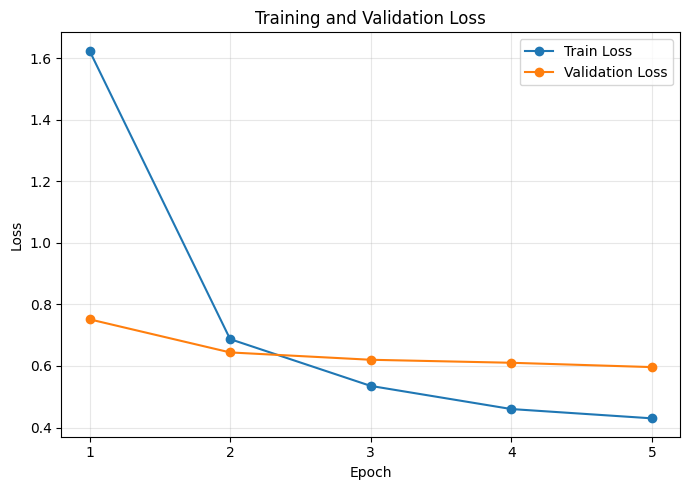

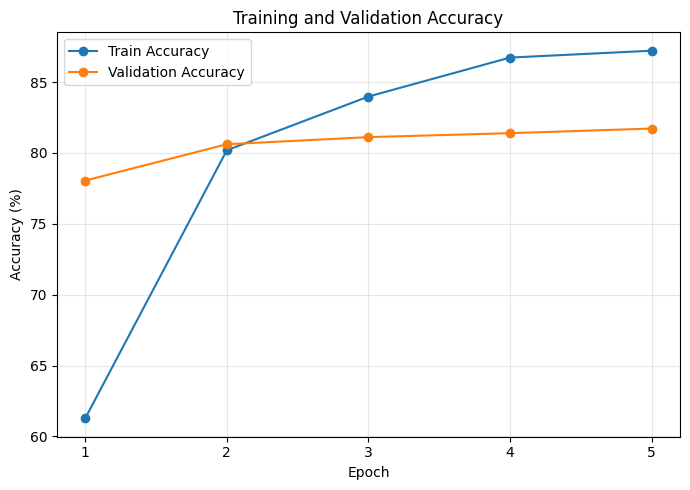

In [39]:
epochs = range(1, 6)

plt.figure(figsize=(7, 5))
plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss",
)
plt.plot(
    epochs,
    history["valid_loss"],
    marker="o",
    label="Validation Loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "training_loss_epoch5.png",
    dpi=150,
)
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(
    epochs,
    np.array(history["train_acc"]) * 100,
    marker="o",
    label="Train Accuracy",
)
plt.plot(
    epochs,
    np.array(history["valid_acc"]) * 100,
    marker="o",
    label="Validation Accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "training_accuracy_epoch5.png",
    dpi=150,
)
plt.show()



```
Train
급격히 계속 개선

Validation
초반 크게 개선 → 이후 완만하게 개선
```



### 이제 동일한 50개 샘플을 5 epoch 학습한 모델에 동일하게 실행합니다.

## 추가 실험(2에서 5로 더 학습함)에서 val accu.가 1.10% 개선된 것을 확인했다.
### IoU도 똑같이 올라갔는지 확인


In [40]:
N_SAMPLES = 50

cam_ious_epoch5 = []
grad_cam_ious_epoch5 = []

for idx in range(N_SAMPLES):
    sample = valid_dataset[idx]

    image_i, label_i, gt_bbox_i = sample

    cam_i = generate_cam(
        model,
        sample,
    )

    grad_cam_i = generate_grad_cam(
        model,
        model.layer4,
        sample,
    )

    cam_i = cv2.resize(
        cam_i,
        (224, 224),
    )

    grad_cam_i = cv2.resize(
        grad_cam_i,
        (224, 224),
    )

    cam_bbox_i = get_bbox(
        cam_i,
        threshold=THRESHOLD,
    )

    grad_bbox_i = get_bbox(
        grad_cam_i,
        threshold=THRESHOLD,
    )

    gt_bbox_i = tuple(
        int(v)
        for v in gt_bbox_i.tolist()
    )

    cam_ious_epoch5.append(
        get_iou(
            gt_bbox_i,
            cam_bbox_i,
        )
    )

    grad_cam_ious_epoch5.append(
        get_iou(
            gt_bbox_i,
            grad_bbox_i,
        )
    )


cam_ious_epoch5 = np.array(
    cam_ious_epoch5
)

grad_cam_ious_epoch5 = np.array(
    grad_cam_ious_epoch5
)

print("=== 5 Epoch Localization ===")

print(
    f"CAM Mean IoU      : "
    f"{cam_ious_epoch5.mean():.4f}"
)

print(
    f"Grad-CAM Mean IoU : "
    f"{grad_cam_ious_epoch5.mean():.4f}"
)

print(
    f"CAM Median IoU      : "
    f"{np.median(cam_ious_epoch5):.4f}"
)

print(
    f"Grad-CAM Median IoU : "
    f"{np.median(grad_cam_ious_epoch5):.4f}"
)

print(
    "CAM better      :",
    np.sum(
        cam_ious_epoch5
        > grad_cam_ious_epoch5
    ),
)

print(
    "Grad-CAM better :",
    np.sum(
        grad_cam_ious_epoch5
        > cam_ious_epoch5
    ),
)

print(
    "Same            :",
    np.sum(
        np.isclose(
            cam_ious_epoch5,
            grad_cam_ious_epoch5,
        )
    ),
)

=== 5 Epoch Localization ===
CAM Mean IoU      : 0.4770
Grad-CAM Mean IoU : 0.4770
CAM Median IoU      : 0.4651
Grad-CAM Median IoU : 0.4651
CAM better      : 0
Grad-CAM better : 0
Same            : 50


## 왜 이번 실험에서는 CAM과 Grad-CAM이 동일하게 나타났는가? 추가 설명:



```
ImageNet으로 미리 학습된 ResNet50 불러오기
                ↓
기존 마지막 분류층 교체
1000개 ImageNet 클래스
        ↓
120개 Stanford Dogs 견종 클래스
                ↓
모델 학습
                ↓
CAM 직접 구현
                ↓
Grad-CAM 직접 구현
                ↓
Bounding Box 생성
                ↓
Ground Truth와 IoU 비교
```



이번 실험 프로세스는
ResNet50 네트워크 자체를 밑바닥부터 코딩한 게 아니라, torchvision이 제공하는 사전학습 ResNet50을 기반 모델로 사용하고 CAM/Grad-CAM 및 localization 평가 과정을 직접 구현했기 때문에



```
ResNet50 + GAP + DenseLayer 결합된 CAM 모델
```



이러한 마지막 분류 구조에서는 두 방식의 채널 중요도가 밀접하게 연결될 수 있으며, 실제 이번 50개 샘플 실험에서는 두 방법이 동일한 IoU를 보였다.